# MediCare Lab - final project
**Educational ML prototype. Not medical diagnosis or prescribing.**

This notebook audits the supplied materials, reproduces model selection without
consulting test scores, evaluates the exact saved pipeline, and checks the app's
input and source-reference contracts. Actual measured accuracy is low; no claim
of clinical usefulness is made. Run all cells from top to bottom using Python 3.12
and `requirements-dev.txt`. No downloads, interactive input, or external datasets
are required. The shipped artifacts are not overwritten by this notebook.

In [1]:
from pathlib import Path
import json, sys, tempfile
import numpy as np
import pandas as pd
from IPython.display import display, Image, Markdown
ROOT = Path.cwd().resolve()
if not (ROOT / 'healthcare').is_dir():
    ROOT = ROOT.parent
assert (ROOT / 'healthcare').is_dir(), 'Run from the project or notebooks directory'
sys.path.insert(0, str(ROOT))
from healthcare.data import prepare_data, binary_features, SYMPTOMS
from healthcare.train import run_experiment
from healthcare.inference import load_bundle, predict, condition_info
bundle = load_bundle(ROOT)
display(pd.Series(bundle.metadata['versions'], name='tested version'))

numpy            2.3.5
pandas           2.2.3
scipy           1.18.1
scikit-learn     1.8.0
joblib           1.5.3
streamlit       1.63.0
Name: tested version, dtype: object

## 1. Source inventory and notebook audit
The archive variants are byte-identical. All three symptom-notebook copies
are byte-identical. A separate personalized-medicine notebook performs text
similarity, not symptom classification. Its catalogue dataset is absent.

The symptom notebook's Training.csv and six supporting CSVs are also missing.
Stored 100% scores cannot be verified. A single test split was reused for model
comparison; there is no protected final test or duplicate audit. Its label
encoder fitted on label names is not itself predictor leakage. The complete
source audit distinguishes confirmed defects from unverified leakage risks.

In [2]:
inventory = json.loads((ROOT / 'reports/source_inventory.json').read_text())
display(pd.DataFrame(inventory['files'])[['name', 'bytes', 'sha256', 'role']])
display(Markdown((ROOT / 'reports/source_audit.md').read_text()))

,name,bytes,sha256,role
0,Medicine_Recommendation_System (1)(1).ipynb,58052,e8c8783d1917d23d8e996136680b74fec62200a593f1b0...,Symptom classification notebook
1,medicare(1).zip,323039,71a6668d41b42c6acd1e004248c9e11361394611f9aaa3...,MediCare source archive
2,Medicine_Recommendation_System (1).ipynb,58052,e8c8783d1917d23d8e996136680b74fec62200a593f1b0...,Symptom classification notebook
3,Medicine_Recommendation_System.ipynb,58052,e8c8783d1917d23d8e996136680b74fec62200a593f1b0...,Symptom classification notebook
4,Personalized_Medicine_Recommending_System (1)....,140684,9ddb926fce06f4d722e4f696fba9a108b398b6d12d5a0b...,Drug catalogue text-similarity notebook
5,medicare.zip,323039,71a6668d41b42c6acd1e004248c9e11361394611f9aaa3...,MediCare source archive


# Source audit

The final project consolidates two distinct notebook workflows and the supplied
MediCare archive. No absent dataset was reconstructed from truncated notebook
output, downloaded from an unrelated project, or replaced with synthetic records.

## Materials examined

| Source | Finding | Final decision |
| --- | --- | --- |
| `medicare.zip`, `medicare(1).zip` | Byte-identical archives; CSV, Flask app, three HTML templates, two model/encoder artifacts, and a medicine dictionary. The archive's data folder is empty. | Retain the complete CSV and source dictionary; rebuild the training and interface code. |
| `Medicine_Recommendation_System.ipynb`, `Medicine_Recommendation_System (1).ipynb`, `Medicine_Recommendation_System (1)(1).ipynb` | Three byte-identical copies, each 26 cells. Stored outputs describe 4,920 rows and 132 symptom features. | Retain the symptom-to-condition workflow and classifier comparison idea, not the unsupported 100% score. |
| `Personalized_Medicine_Recommending_System (1).ipynb` | 37 cells; a drug-to-drug text similarity demo on a reported 9,720-row dataset. This is a different task. | Audit and exclude from disease prediction and prescribing. |

The original three earlier notebooks are the two `Medicine_Recommendation_System`
variants and the `Personalized_Medicine_Recommending_System` notebook. The current
turn supplied one further identical symptom-notebook copy. SHA-256 checksums and
file sizes are in `source_inventory.json`.

## Confirmed defects in the archive

1. `Cleaned_Dataset.csv` has 349 rows, 14 columns, no missing cells, 116 original
   disease labels, and 49 exact duplicate rows. There are only four binary symptom
   features: at most 16 observable patterns. All 16 map to multiple disease labels.
2. `risk_level` is constant within each of the 116 disease labels. It is a target
   proxy unavailable to a symptom-only user. `outcome_variable` is an outcome with
   undocumented timing. Neither belongs in this prediction contract.
3. All three supplied scaled columns numerically match StandardScaler fitted on
   the complete 349-row dataset (checked with NumPy allclose). That is global
   preprocessing, not training-fold preprocessing. Scaled copies are also redundant.
4. The persisted model's statically inspected schema includes the risk, outcome,
   and scaled fields. The label encoder lists only nine labels, including an
   undocumented `Other` aggregation. Its training source and evaluation are absent.
5. Flask replaces missing scaled values with raw values and missing outcome/risk
   values with zero. It sends numeric symptom values although the source uses
   Yes/No categories. This changes the training input representation.
6. The model chooser changes a response string but still calls the same loaded
   model. A separate hardcoded risk rule has no demonstrated validation. The HTML
   claims 95%+ accuracy and clinical use without supplied evidence.
7. The medicine dictionary and the app's second hardcoded dictionary disagree.
   Some entries contain unverified prescription doses, region-specific emergency
   numbers, and contradictory emergency medication directions. The final app uses
   one traceable source, omits all doses, schedules, advice/triage instructions,
   and withholds Stroke recommendation fields entirely.
8. The contact template includes unrelated contact details and a success message;
   the final project removes this copied contact flow and all diagnostic marketing.

## Symptom notebook audit

- Missing: `Training.csv`, `symtoms_df.csv`, `precautions_df.csv`, `workout_df.csv`,
  `description.csv`, `medications.csv`, and `diets.csv`. The stored outputs do not
  supply those full files. The notebook cannot run from the uploads alone.
- Cell 9 makes one random 70/30 split without stratification or duplicate/group
  checks. Cell 11 compares five classifiers on that same test set; cells 13-17
  reuse it after choosing SVC. No untouched final evaluation is supplied.
- All five displayed accuracies are 1.0. These are historical outputs, not newly
  verified results. Duplicate leakage is a risk, not a confirmed fact for the
  unavailable Training.csv. Its provenance and independence cannot be established.
- Fitting LabelEncoder on the list of labels is not itself predictor leakage;
  label-name enumeration is distinct from learning predictor transformations.
- Cell 21 uses a hardcoded symptom order and label map. The description helper
  reads a global `predicted_disease` instead of its argument. Unknown symptoms
  raise a KeyError; an empty feature vector can still produce a condition label.
- The source saves the SVC alone and relies on separate hardcoded mappings. The
  new model stores its fitted pipeline and validates feature/class metadata.

## Drug similarity notebook audit

- `medicine.csv` is missing. Stored output describes 9,720 medicine catalogue rows;
  this is not a symptom-labelled training dataset.
- CountVectorizer on description plus reason and cosine similarity retrieve text
  neighbors. There is no independent relevance test, prescribing-safety evaluation,
  or evidence that similar text means interchangeable medication.
- Including `Reason` as text is valid catalogue retrieval metadata; it would be
  target leakage only if this were repurposed to predict Reason. No such supervised
  accuracy is claimed here.
- A dense 9,720 x 9,720 similarity matrix has 94,478,400 entries (about 756 MB at
  float64), and is calculated more than once. Query-time sparse similarity would
  be preferable if this distinct retrieval task were resumed.
- Exact-name lookup crashes on missing names. Slicing off the first ranked row
  assumes the self-match comes first; duplicate names/tied similarities can return
  the original drug. The stored example does return its query drug among results.

## What is preserved and what is missing

Preserved: original CSV bytes, original medicine dictionary contents as inert JSON,
the symptom-selection concept, and comparison of standard classifiers. Added:
explicit scope, leakage controls, reproducible artifacts, tests, source fidelity,
and an honest UI. Original model pickles and duplicate notebooks are not shipped
as runnable dependencies. The original dictionary was converted with a restricted
unpickler that forbids global/class loading and persistent references.

No clinical study, source publisher, collection method, patient identifier,
collection date, license, disease descriptions, or verified clinical references
were supplied for the archive data. Do not assert these are real patient records
or that the original authors licensed them for public redistribution. Similar
labels and truncated names remain unchanged; no guessed medical aliases are merged.


## 2. Audit the complete available table
Keep the source bytes unchanged. Remove exact raw-profile/label duplicates;
keep contradictory labels rather than guessing a correction. Define eligibility
at five unique profiles per label before creating the split. This limits the
benchmark to a subset of source conditions and is not open-world diagnosis.

In [3]:
raw, clean, study, scope = prepare_data(ROOT / 'data/raw/Cleaned_Dataset.csv')
display(pd.Series(bundle.audit))
display(raw.head())
display(scope.sort_values('unique_profiles', ascending=False).head(35))
assert len(raw) - len(clean) == 49
assert len(study) == 195 and study.disease.nunique() == 28

source_sha256                          620442d1788959909993d0a4b0a29df29c8bc5eae3a04b...
raw_rows                                                                             349
raw_columns                                                                           14
raw_labels                                                                           116
missing_cells                                                                          0
duplicate_rows_removed                                                                49
clean_rows                                                                           300
conflicting_full_profile_groups                                                       45
symptom_patterns                                                                      16
ambiguous_symptom_patterns                                                            16
max_labels_per_symptom_pattern                                                        65
deterministic_symptom

,source_row,disease,fever,cough,fatigue,difficulty_breathing,age,gender,blood_pressure,cholesterol_level,outcome_variable,age_scaled,bp_scaled,chol_scaled,risk_level
0,0,Influenza,Yes,No,Yes,Yes,19,female,0,1,Positive,-2.091160,-2.419529,-0.576777,Low
1,1,Common Cold,No,Yes,Yes,No,25,female,1,1,Negative,-1.631964,-0.723915,-0.576777,Low
2,2,Eczema,No,Yes,Yes,No,25,female,1,1,Negative,-1.631964,-0.723915,-0.576777,Medium
3,3,Asthma,Yes,Yes,No,Yes,25,male,1,1,Positive,-1.631964,-0.723915,-0.576777,Medium
4,4,Asthma,Yes,Yes,No,Yes,25,male,1,1,Positive,-1.631964,-0.723915,-0.576777,Medium


,condition,unique_profiles,included
6,Asthma,16,True
77,Osteoporosis,12,True
101,Stroke,11,True
32,Diabetes,10,True
51,Hypertension,10,True
69,Migraine,10,True
56,Influenza,7,True
84,Pneumonia,7,True
13,Bronchitis,7,True
24,Common Cold,6,True


In [4]:
from sklearn.preprocessing import StandardScaler
scaled_pairs = [('age', 'age_scaled'), ('blood_pressure', 'bp_scaled'), ('cholesterol_level', 'chol_scaled')]
global_scale_check = {a: np.allclose(StandardScaler().fit_transform(raw[[a]]).ravel(), raw[b]) for a, b in scaled_pairs}
display(pd.Series(global_scale_check, name='matches scaler fitted on ALL source rows'))
display(raw.groupby('disease').risk_level.nunique().value_counts().rename('disease labels'))
ambiguity = raw.groupby(list(SYMPTOMS)).disease.nunique().rename('distinct labels').reset_index()
display(ambiguity)
assert ambiguity['distinct labels'].gt(1).all()

age                  True
blood_pressure       True
cholesterol_level    True
Name: matches scaler fitted on ALL source rows, dtype: bool

risk_level
1    116
Name: disease labels, dtype: int64

,fever,cough,fatigue,difficulty_breathing,distinct labels
0,No,No,No,No,11
1,No,No,No,Yes,2
2,No,No,Yes,No,65
3,No,No,Yes,Yes,5
4,No,Yes,No,No,19
5,No,Yes,No,Yes,4
6,No,Yes,Yes,No,17
7,No,Yes,Yes,Yes,10
8,Yes,No,No,No,16
9,Yes,No,No,Yes,3


**Interpretation.** The supplied scaled columns match full-dataset scaling.
They and the disease-derived risk field are excluded. The outcome's timing is
undocumented, so it is excluded too. Age, gender, blood pressure and cholesterol
are used only to group repeated profiles, never as inputs to this symptom-only
interface. Four binary inputs cannot uniquely encode these labels. The computed
majority-per-pattern ceiling is a descriptive in-sample bound, not validation.

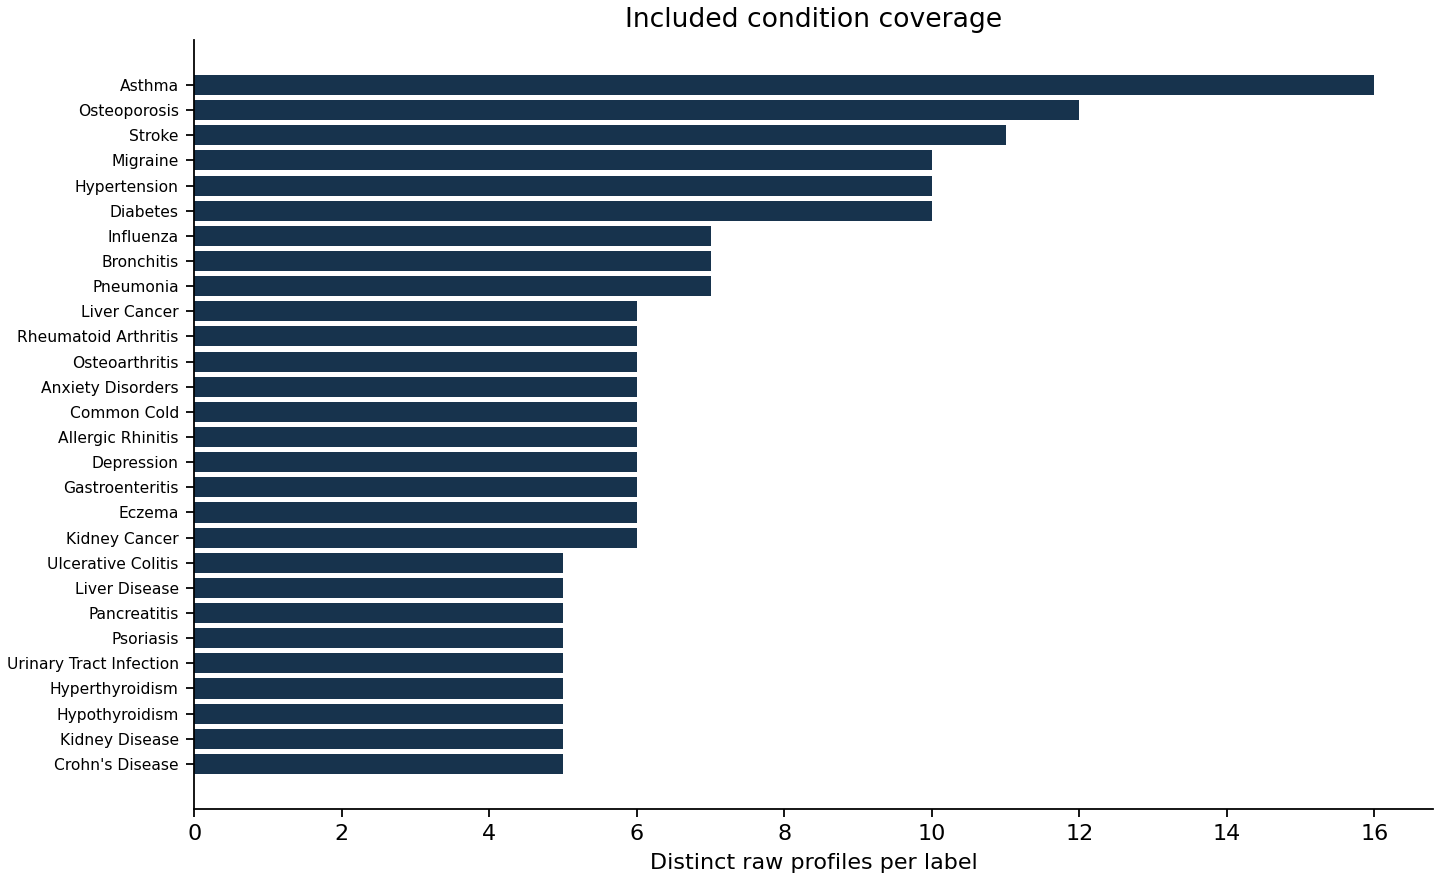

In [5]:
display(Image(filename=str(ROOT / 'reports/figures/class_support.png')))


## 3. Fixed evaluation protocol
Use the first five-fold StratifiedGroupKFold partition with seed 42 as the
holdout. Compare seven fixed candidate classifiers in four grouped CV folds
within training. Select by macro F1, then balanced accuracy, then predefined
simplicity order. Evaluate only the selected model and the dummy baseline on
the holdout. Save the exact evaluated fit; do not train on the holdout afterward.

Full raw-profile groups cannot cross train/test or CV partitions. They are a
proxy, not patient identifiers. Different profiles can share symptoms across
the split. A supplementary training-only GroupKFold challenge holds out whole
symptom patterns and is never used to choose a model.

In [6]:
manifest = pd.read_csv(ROOT / 'reports/split_manifest.csv')
display(pd.crosstab(manifest.disease, manifest.split))
assert manifest.groupby('profile_group').split.nunique().max() == 1
assert manifest.query("split == 'train'").groupby('profile_group').cv_validation_fold.nunique().max() == 1
display(pd.Series(manifest.split.value_counts(), name='split rows'))

split,test,train
disease,,
Allergic Rhinitis,2,4
Anxiety Disorders,1,5
Asthma,3,13
Bronchitis,2,5
Common Cold,1,5
Crohn's Disease,1,4
Depression,1,5
Diabetes,2,8
Eczema,1,5


split
train    157
test      38
Name: split rows, dtype: int64

## 4. Reproduce training and compare classifiers
The following reruns the fixed experiment in a temporary directory, then
asserts parity with the shipped artifacts. These checks verify reproducibility;
they do not search for a better test score or change the model after evaluation.

Verified identical selection, scores, test predictions, and group partitions.


,model,cv_macro_f1_mean,cv_macro_f1_std,cv_accuracy_mean,cv_balanced_accuracy_mean
0,Random forest,0.045181,0.007893,0.095722,0.073661
1,Logistic regression,0.029138,0.008864,0.076635,0.062500
2,K nearest neighbors,0.025758,0.012054,0.070225,0.043155
3,Bernoulli Naive Bayes,0.023087,0.009029,0.063815,0.053571
4,Linear SVM,0.021471,0.003536,0.063983,0.058036
5,Decision tree,0.014223,0.005164,0.044415,0.035714
6,Dummy prior,0.005445,0.000525,0.082589,0.035714


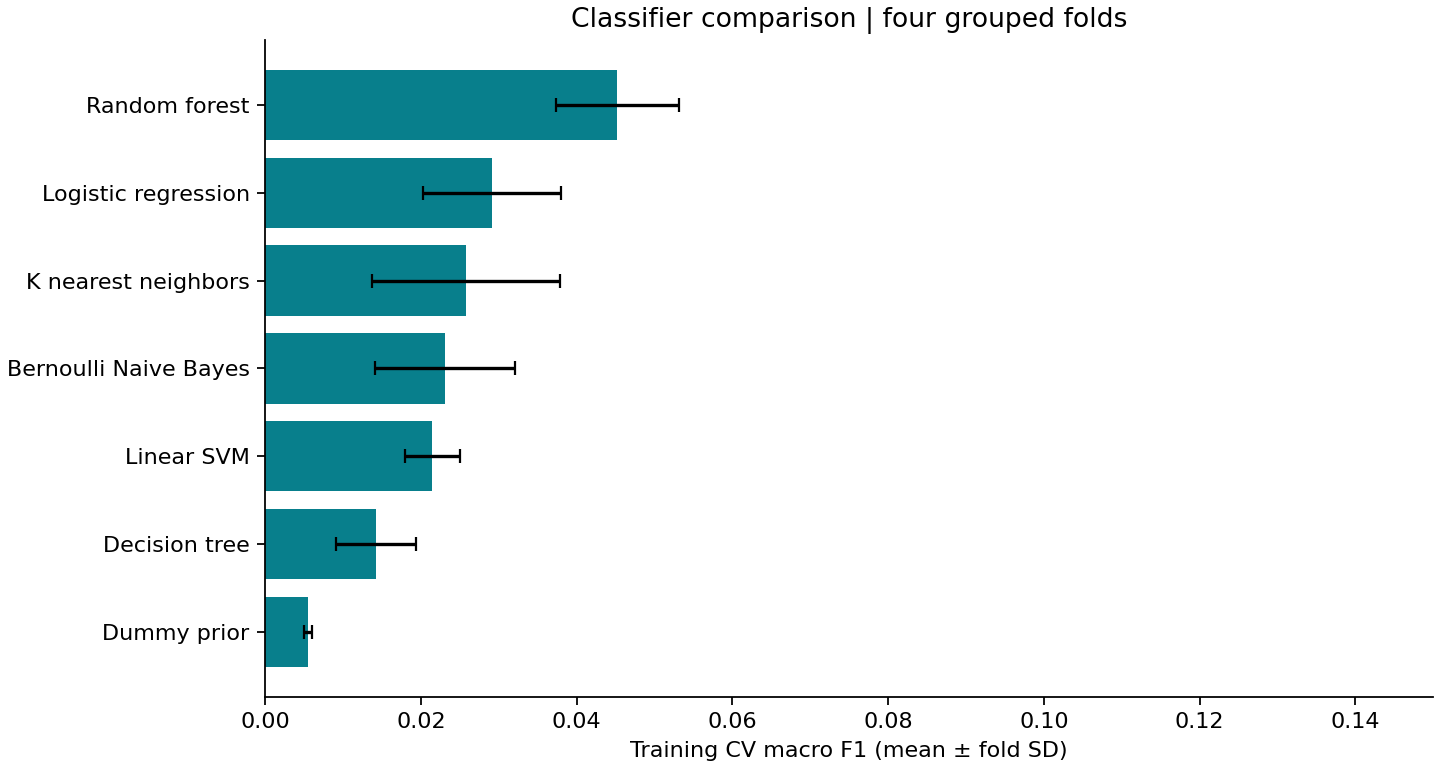

In [7]:
reproduction_dir = tempfile.TemporaryDirectory(prefix='medicare_reproduction_')
reproduced = run_experiment(ROOT, Path(reproduction_dir.name))
comparison = reproduced['comparison']
display(comparison[['model', 'cv_macro_f1_mean', 'cv_macro_f1_std', 'cv_accuracy_mean', 'cv_balanced_accuracy_mean']])
assert reproduced['evaluation'] == bundle.evaluation
for filename in ['split_manifest.csv', 'test_predictions.csv', 'model_comparison.csv']:
    pd.testing.assert_frame_equal(pd.read_csv(ROOT / 'reports' / filename), pd.read_csv(Path(reproduction_dir.name) / 'reports' / filename))
print('Verified identical selection, scores, test predictions, and group partitions.')
display(Image(filename=str(ROOT / 'reports/figures/model_comparison.png')))

## 5. Final held-out evaluation and error analysis
Accuracy counts correct labels. Macro F1 weights every configured condition
equally; macro precision/recall/F1 include all 28 labels with zero division
handled explicitly. Balanced accuracy averages recall across labels present
in each fold. Top-3 is a ranking metric, not a clinical differential diagnosis.
Confidence intervals are conditional on this small, fixed dataset and split.

95% profile-group bootstrap accuracy interval: [0.0, 0.1388888888888889]


,selected model,dummy prior
accuracy,0.052632,0.078947
macro_f1,0.029762,0.005226
macro_precision,0.047619,0.002820
macro_recall,0.023810,0.035714
balanced_accuracy,0.023810,0.035714
weighted_f1,0.065789,0.011553
top3_accuracy,0.131579,0.184211
rows,38.000000,38.000000
labels_present,28.000000,28.000000


,condition,precision,recall,f1-score,support
0,Allergic Rhinitis,0.000000,0.000000,0.000000,2.000000
1,Anxiety Disorders,0.000000,0.000000,0.000000,1.000000
2,Asthma,1.000000,0.333333,0.500000,3.000000
3,Bronchitis,0.000000,0.000000,0.000000,2.000000
4,Common Cold,0.000000,0.000000,0.000000,1.000000
5,Crohn's Disease,0.000000,0.000000,0.000000,1.000000
6,Depression,0.000000,0.000000,0.000000,1.000000
7,Diabetes,0.000000,0.000000,0.000000,2.000000
8,Eczema,0.000000,0.000000,0.000000,1.000000
9,Gastroenteritis,0.000000,0.000000,0.000000,1.000000


,source_row,disease,predicted,fever,cough,fatigue,difficulty_breathing
0,0,Influenza,Common Cold,Yes,No,Yes,Yes
1,11,Allergic Rhinitis,Psoriasis,No,Yes,Yes,No
2,12,Anxiety Disorders,Hypertension,No,Yes,No,No
3,16,Pancreatitis,Psoriasis,Yes,No,No,No
4,28,Migraine,Psoriasis,Yes,No,No,No
5,56,Asthma,Urinary Tract Infection,No,Yes,Yes,Yes
6,63,Eczema,Hypertension,No,Yes,No,No
8,79,Depression,Hypothyroidism,No,No,Yes,No
9,81,Hyperthyroidism,Crohn's Disease,Yes,Yes,Yes,No
10,83,Kidney Cancer,Hypothyroidism,No,No,Yes,No


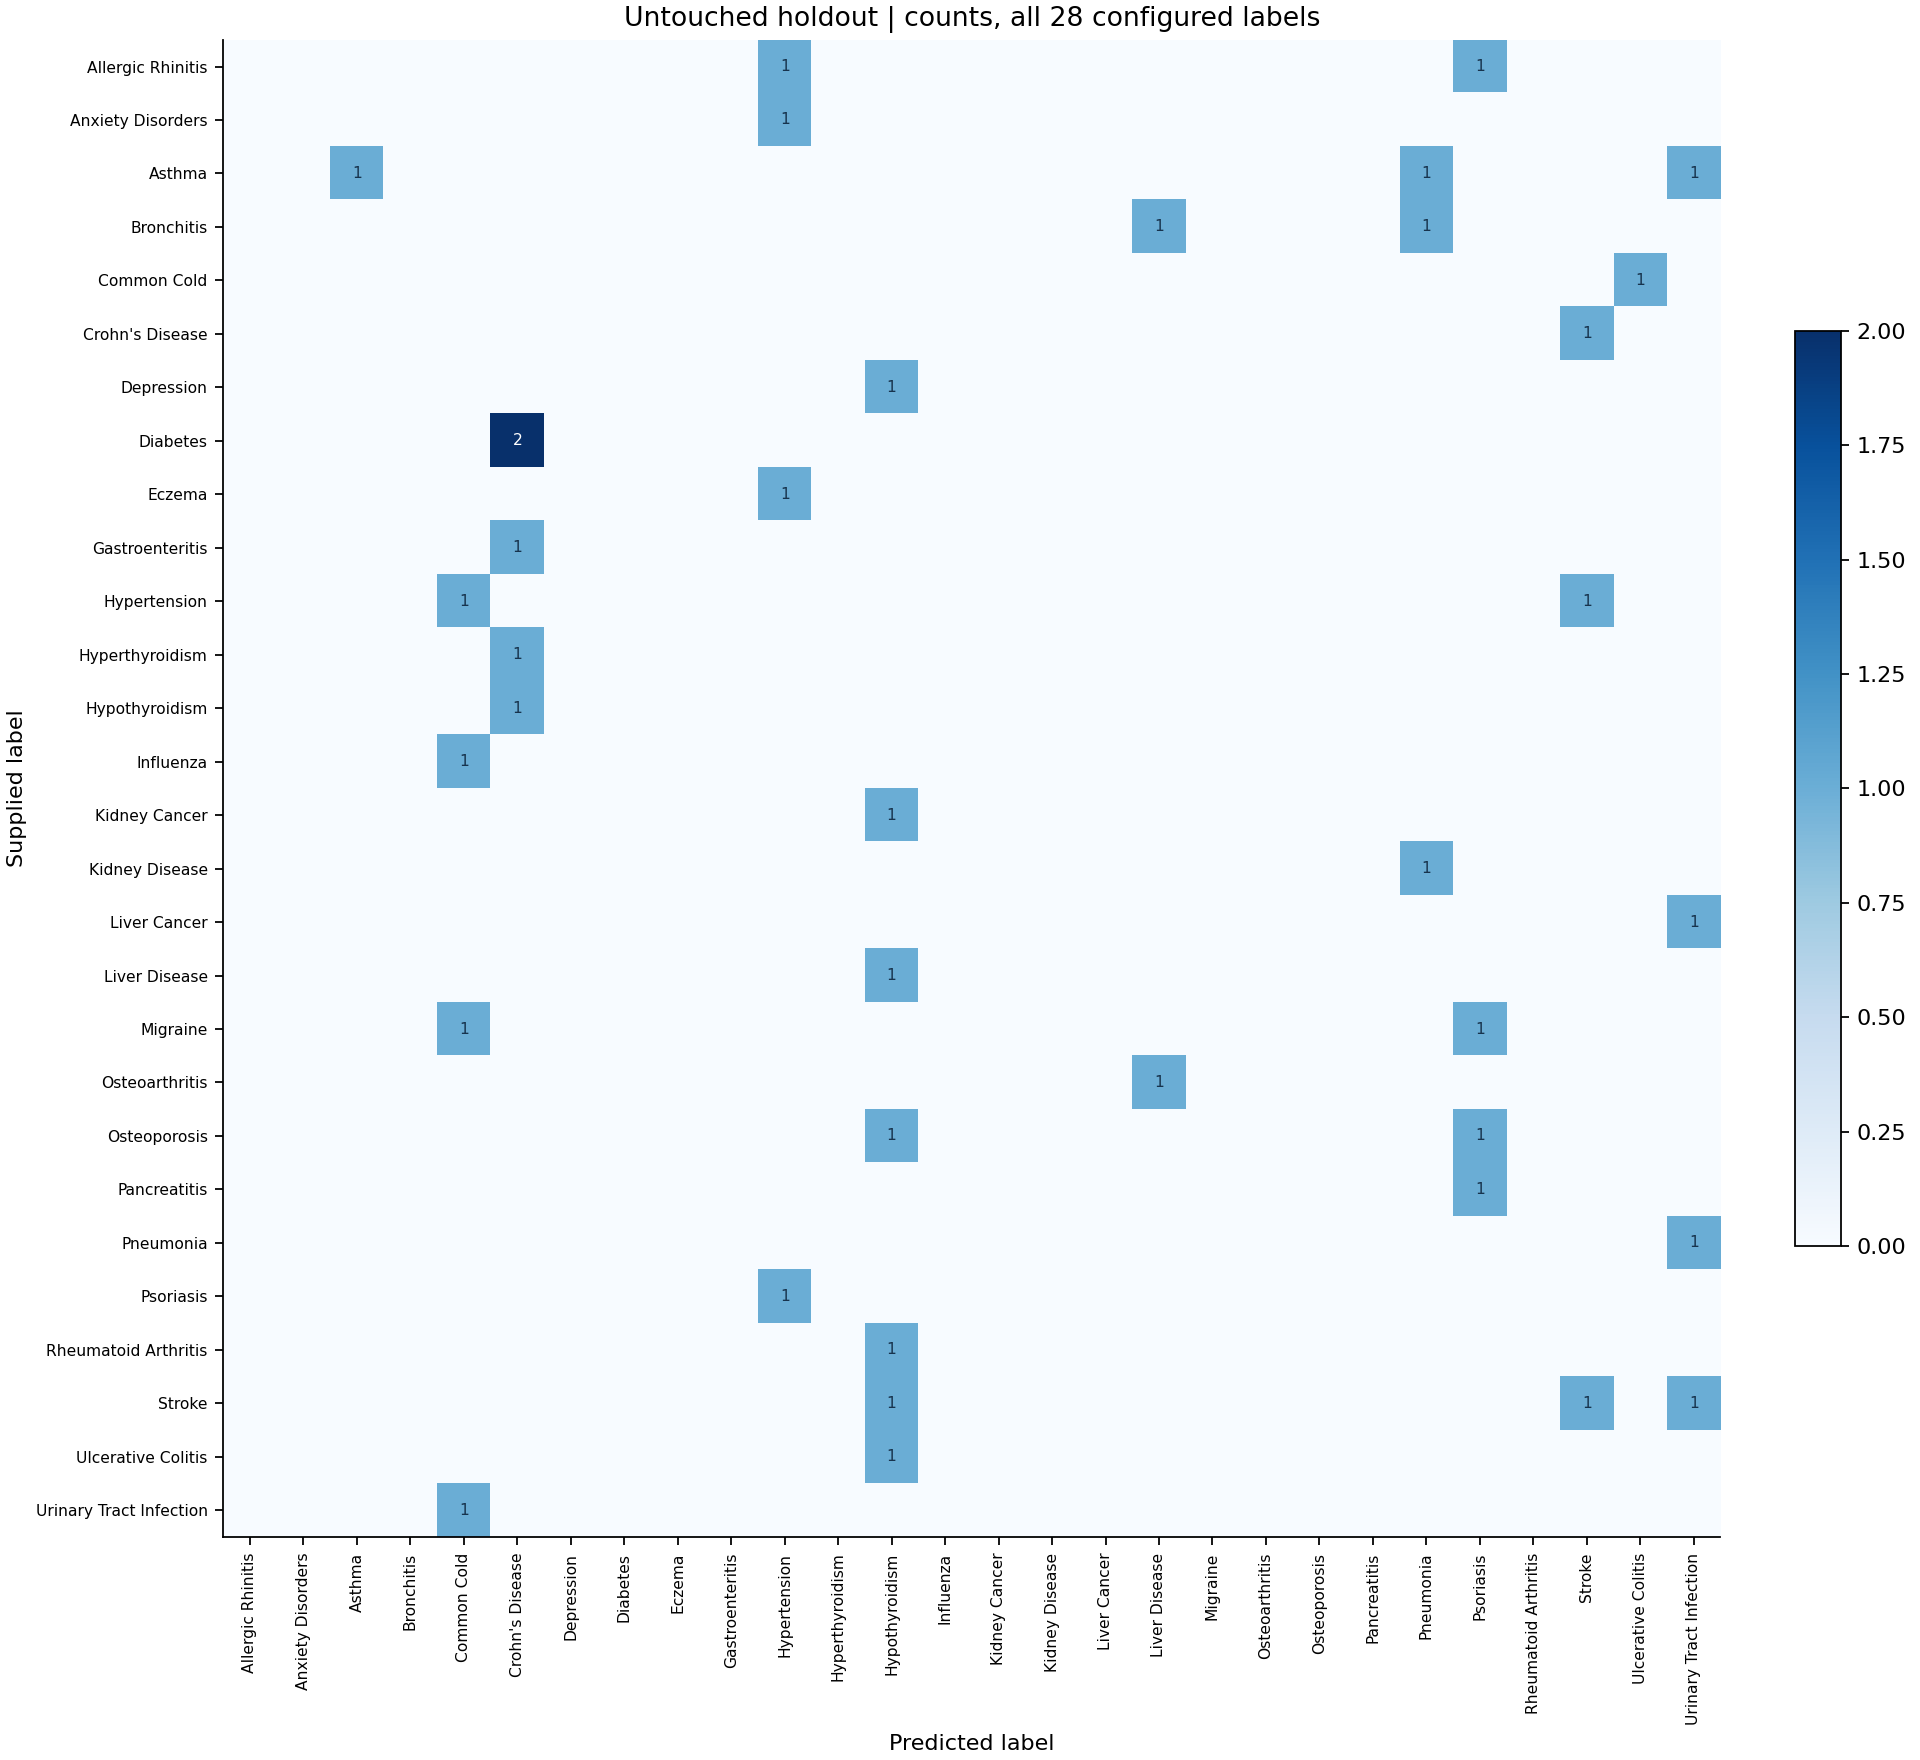

In [8]:
ev = bundle.evaluation
display(pd.DataFrame({'selected model': ev['holdout'], 'dummy prior': ev['dummy_holdout']}))
print('95% profile-group bootstrap accuracy interval:', ev['holdout_accuracy_cluster_bootstrap_95'])
display(pd.read_csv(ROOT / 'reports/classification_report.csv'))
errors = pd.read_csv(ROOT / 'reports/test_predictions.csv')
display(errors.loc[~errors.correct, ['source_row', 'disease', 'predicted', *SYMPTOMS]].head(15))
display(Image(filename=str(ROOT / 'reports/figures/confusion_matrix.png')))

**Result.** Random forest was chosen by training CV macro F1
(Training-only four-fold grouped macro F1; then balanced accuracy; then simplicity order.). On the untouched holdout, accuracy is
5.26% and macro F1 is 0.0298.
It is worse than the dummy baseline in accuracy and top-3 accuracy. The dataset
is inadequate for reliable diagnosis; no attempt is made to conceal or optimize
away this negative result by switching models on the test data.

In [9]:
stress = pd.read_csv(ROOT / 'reports/unseen_pattern_stress.csv')
display(stress)
print('Training-only unseen-pattern mean macro F1:', ev['train_only_unseen_pattern_stress_macro_f1'])

Training-only unseen-pattern mean macro F1: 0.003698979591836735


,fold,accuracy,macro_f1,macro_precision,macro_recall,balanced_accuracy,weighted_f1,top3_accuracy,rows,labels_present,unseen_labels
0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.050000,40,23,[]
1,1,0.025000,0.007143,0.005102,0.011905,0.015152,0.015000,0.100000,40,22,[]
2,2,0.076923,0.007653,0.004464,0.026786,0.034091,0.021978,0.205128,39,22,[]
3,3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.105263,38,23,[]


## 6. Saved model and application inference
The application calls the same `predict` function below. Symptom order is
fixed by a saved schema, unselected symptoms mean absent after confirmation,
and empty/unknown inputs are rejected. No extra clinical inputs are invented.

In [10]:
example = predict(bundle, ['cough', 'difficulty_breathing'])
display(example)
test_rows = pd.read_csv(ROOT / 'reports/test_predictions.csv')
assert bundle.model.predict(binary_features(test_rows)).tolist() == test_rows.predicted.tolist()
display(condition_info(bundle, example['predicted_condition']))

{'predicted_condition': 'Liver Disease',
 'ranked_conditions': ['Liver Disease', 'Kidney Disease', 'Asthma'],
 'selected_symptoms': ['cough', 'difficulty_breathing'],
 'matching_training_rows': 2,
 'matching_training_labels': 2,
 'training_pattern_seen': True,
 'clinical_assessment': 'Insufficient evidence for a reliable medical conclusion.',
 'educational_only': True}

{'condition': 'Liver Disease',
 'source_profiles': 5,
 'included_in_model': True,
 'symptom_counts': {'fever': 2,
  'cough': 3,
  'fatigue': 3,
  'difficulty_breathing': 2},
 'reference': None,
 'description': 'No disease description was supplied in the available reference dataset.'}

## 7. Source-grounded information and recommendations
The archive's medicine dictionary supplies ten reference records but no disease
descriptions. Exact medicine-name substrings and verbatim food/course entries
are exposed only as unverified study material. Missing entries are explicit.
No dosage, medication substitution, emergency medication instructions, or
generated medical text is displayed. Stroke recommendation fields are withheld
because of internal source contradictions. Clinical verification is absent.

In [11]:
reference = bundle.reference['Asthma']
display({k: reference[k] for k in ['source', 'verified_medically', 'description_status', 'medicine_names']})
assert all(not any(ch.isdigit() for ch in item['text']) for item in reference['medicine_names'])
assert bundle.reference['Stroke']['withheld']
assert condition_info(bundle, 'Osteoporosis')['reference'] is None
assert not condition_info(bundle, 'Acne')['included_in_model']

{'source': 'medicare.zip / medicine_database.pkl',
 'verified_medically': False,
 'description_status': 'No disease description was supplied in the available reference dataset.',
 'medicine_names': [{'text': 'Albuterol (Rescue Inhaler)',
   'source_field': 'medicines',
   'source_index': 0,
   'source_text_sha256': '0c5c34064fa4abc3a8be06b3535e77b95757f722586cf2a7bdcef2104a884468'},
  {'text': 'Fluticasone (Controller)',
   'source_field': 'medicines',
   'source_index': 1,
   'source_text_sha256': '75da5102ac1765d3b81a52732074192e9e7f93d52644a54c81751560dc627cb2'},
  {'text': 'Montelukast',
   'source_field': 'medicines',
   'source_index': 2,
   'source_text_sha256': 'c2e6f4d1c0b29d3abe5c7bf5e9d440b592eb3dc07f3069dee52051e91867b509'}]}

## 8. Validation evidence
Functional tests execute the real Streamlit app using its AppTest API. They
cover all 15 non-empty input patterns, empty-input/confirmation handling,
stale-result removal, present/missing/withheld references, and the evaluation
page. Additional tests check group separation, source fidelity and artifact
integrity. See the recorded test files; rerun with `python -m pytest`.

In [12]:
import xml.etree.ElementTree as ET
results = ET.parse(ROOT / 'reports/test_results.xml').getroot()
display([s.attrib for s in results.iter('testsuite')])
browser_path = ROOT / 'screenshots/browser_checks.json'
if browser_path.exists():
    display(json.loads(browser_path.read_text()))
reproduction_dir.cleanup()

[{'name': 'pytest',
  'errors': '0',
  'failures': '0',
  'skipped': '0',
  'tests': '31',
  'time': '4.645',
  'timestamp': '2026-09-14T17:28:42.062751+03:00',
  'hostname': 'localhost'}]

{'url': 'localhost Streamlit server',
 'browser': 'Chromium',
 'checks_passed': ['Empty input rejected in live browser',
  'Symptom selection and model result rendered',
  'Opt-in exact source names displayed without dose instructions',
  'Evaluation page and plot rendered',
  'No desktop horizontal overflow',
  '390px mobile layout renders without horizontal overflow'],
 'javascript_errors': [],
 'desktop_viewport': [1440, 1800],
 'mobile_viewport': [390, 1800],
 'screenshots': ['symptom_explorer.png',
  'condition_reference.png',
  'model_evaluation.png',
  'mobile_explorer.png']}

## Final conclusion
The software is complete and reproducible. The supplied dataset does **not**
establish clinical capability. Recover the missing original datasets and their
provenance, obtain richer governed data with patient/site/time grouping,
validate all reference information with qualified reviewers, and define a new
external evaluation before pursuing any health-related real-world use.

Technical references: [scikit-learn common pitfalls](https://scikit-learn.org/stable/common_pitfalls.html),
[StratifiedGroupKFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedGroupKFold.html),
[Streamlit AppTest](https://docs.streamlit.io/develop/api-reference/app-testing/st.testing.v1.apptest).
These sources support implementation practices, not medical information.